<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Introduction](#introduction)
- [The Dataset](#the-dataset)
- [Complex Network Feature Engineering](#complex-network-feature-engineering)
- [Model Selection](#model-selection)
- [Tabular vs. Complex Network](#tabular-vs.-complex-network)
- [Conclusion](#conclusion)

</div>

### ORIENTATION:

This file is an overall narration of this entire project starting from the underlying motivations and direction of this project, key decision and implementation points, and key findings from this project

In [1]:
# Imports for usability
import wrangle as w                     # Functions used during data wrangle process
import explore_normal_data as eND       # Functions used during normal/tabular data exploration
import explore_complex_networks as eCN  # Functions used during complex network engineering/exploration
import modeling as m                    # Functions used during modeling
import final as f                       # Functions specific to the final presentation
import pandas as pd                     # Dataframing
import joblib                           # ML loading
from tensorflow import keras            # NN loading

/opt/anaconda3/envs/COMP3703/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-15 11:50:54.391834: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load in the tabular/complex datasets
tabular_df = pd.read_parquet('datasets/prepared_normal_short.parquet')
complex_df = pd.read_parquet('datasets/prepared_complex.parquet')

![Alt text](finalImages/beholdTheBlackBox.png)

![Alt text](finalImages/confusingAI.png)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Introduction

- [Back to Table of Contents](#table-of-contents)

</div>

### PROJECT MOTIVATION:

**KEY POINTS:**
- Avoid notorious "black box" Artifical Intelligence (AI) models (i.e. Neural Networks)
- Emphasize explainable AI that inherenetly derives more value

The realm of Artificial Intelligence (AI) is rapidly growing and improving at an exponential rate over the last few years.  Around the world and in nearly every field - Some more so than others - AI is being implemented to improve overall efficiency, efficacy, or sometimes both at the same time.  Though held in high-regard for its efficient method of ingesting and computing data making these models appear smart, they are nothing more than just a very efficient way of brute-forcing patterns into existance - Even if the pattern actually doesn't exist - and computing weights and biases to ensure the desired outcome is achieved more often than not.  For this reason, when the model gives us something wrong, especially in a high-stakes scenario, everyone looks to the AI engineer(s) to explain to them why the wrong answer was given by the model.  Unfortunately, the likely answer will be an overly ambiguous answer and blaming of faulty data leaving everyone frustrated when the issue lies simply in the fact of a AI's - more specifically Neural Networks (NN) - concept and heavy reliance of backpropagation.  Backpropagation is best visualized as a decision tree where from some start node, we incrementally make decisions along the tree until we get to the final node, which in this case is the output node, and what we get is what we get; However, for backpropagation, if this answer is wrong, it will walk backwards and adjust things known as weights and biases for every decision made to ensure that the correct output node is arrived at.  For simplicity's sake, these are exactly what they sound like and are just an additive or removal of emphasis on which decisions to choose depending on the intial node.  Now imagine doing this process not just for one node, but for millions, billions, perhaps trillions of nodes.  Now when someone asks you why the model gave you the wrong answer, do you think you can effectively explain why the model was wrong and make a tentative plan to remedy the faulty performance?  If so, you're an unmatched genius, but I would argue that most people can't comprehend all the math going on "under-the-hood", but because it tends to derive the right answer enough and fast enough, most people just blindly trust the model and tweak various methodologies of how this model performs.  This disconnect in explainability is the notorious concept of the "black box" and this concept is what I want to explore and avoid in AI implementation.  In short, I want to feature engineer rich data associated with a dataset that inherently makes AI models perform better, yet I can explain exactly what is going on within the AI and why.

---

### PROJECT SCOPE:

**KEY POINTS:**
- Feature Engineer Complex Network from a dataset
- Create as close of a Machine Learning (ML) model and NN to send model training
- Train the first set of models only on the tabular data (Non-complex network data)
- Train the second set of models only on the complex network data
- Evaluate and observe performance differences

Given the scope is explainability of AI performance, one can typically achieve this via Subject-Matter-Expertise (SME) or underlying patterns and formulaic expression generally proven through higher-level mathematics.  Given that a SME is specific to a field, the likelihood of being a SME for most situations is a pipe-dream and thus, I would rather rely on understanding fundamental mathematics that could potentially expose hidden patterns of data.  For this reason, complex network ideology for mathematics is the most likely and most applicable candidate from my perspective in deriving such hidden patterns.  This is to say that the objective is to implement mathematic complex network ideology in hopes that it performs better than the original dataset which we will call the tabular dataset and the complex network ideology the complex network dataset respectively.  Now the question is how can we effectively determine whether or not the complex network data intrinsically provides better performance than the tabular dataset.  Generally speaking, ML models are much easier to explain than NNs because ML models don't use backpropagation and each ML model has a very specific way of training itself that is usually easy to understand.  Thus, in evaluating whether or not the complex network dataset intrinsically provides more value than the tabular dataset, we will define - as close as possible - a generic ML model and an NN where the first set is trained on the tabular dataset and the second set is trained on the complex network dataset.  Ideally, we want to observe that the ML model trained with the complex network dataset performs better than the ML model trained on the tabular dataset.  This is largely because of the explainability capabilities and the NN comparison is generally to observe the case of performance where the tabular dataset obfuscates patterns in the dataset leaving the NN to figure it out compared with the complex network dataset where the dataset patterns are provided intitially for the model training.

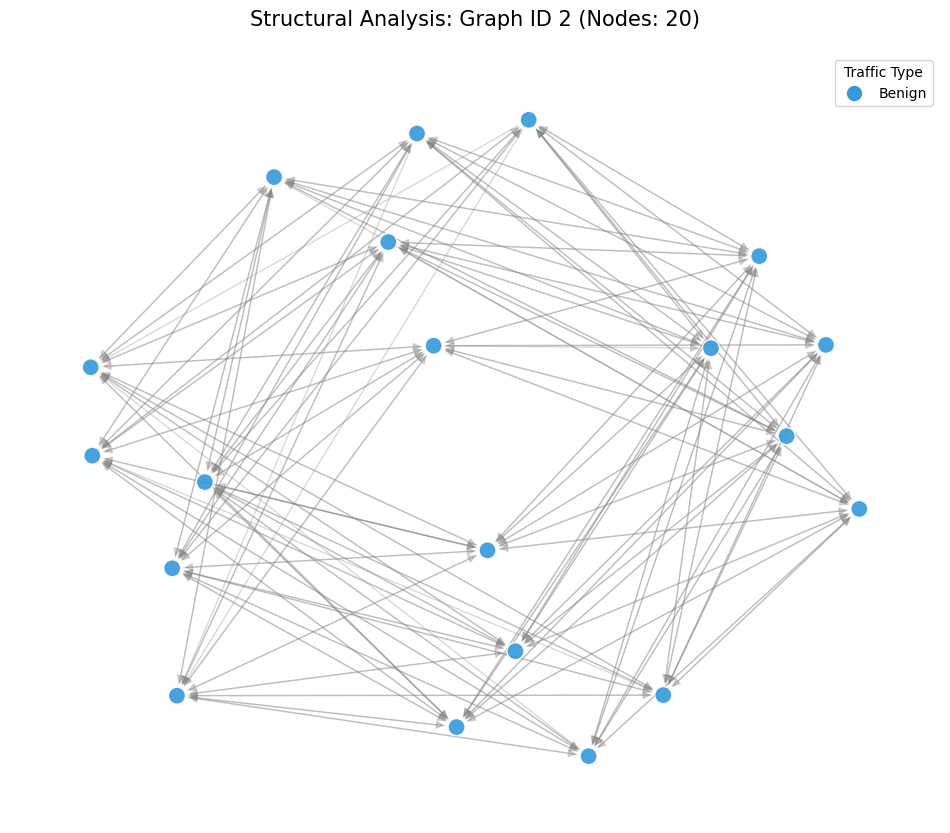

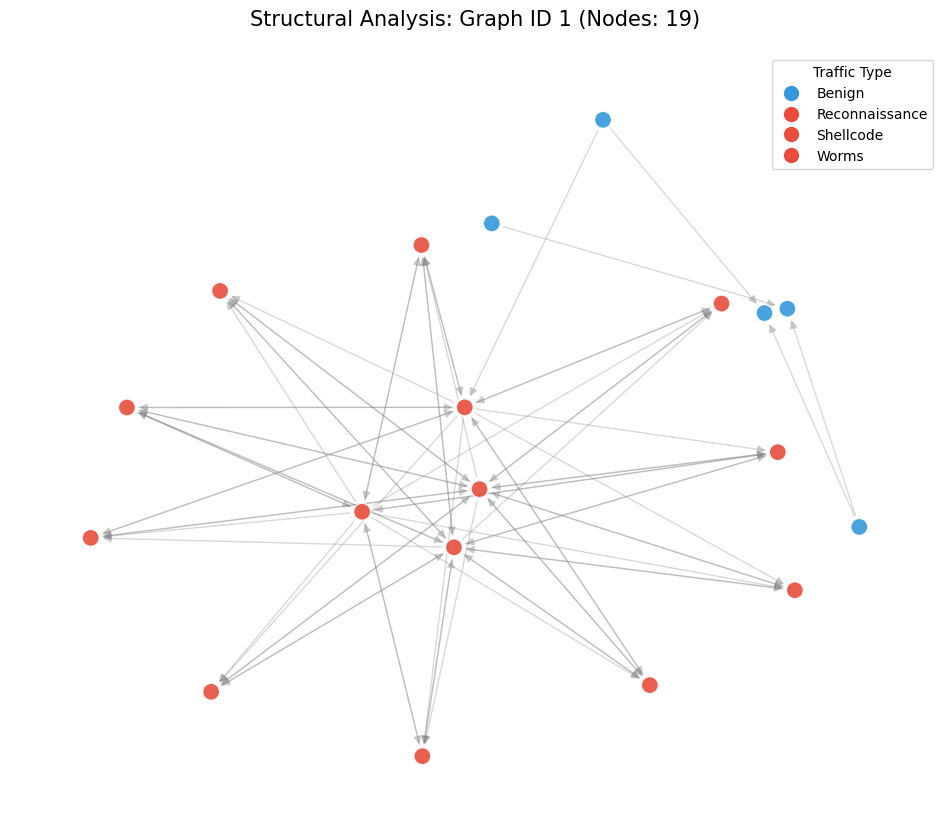

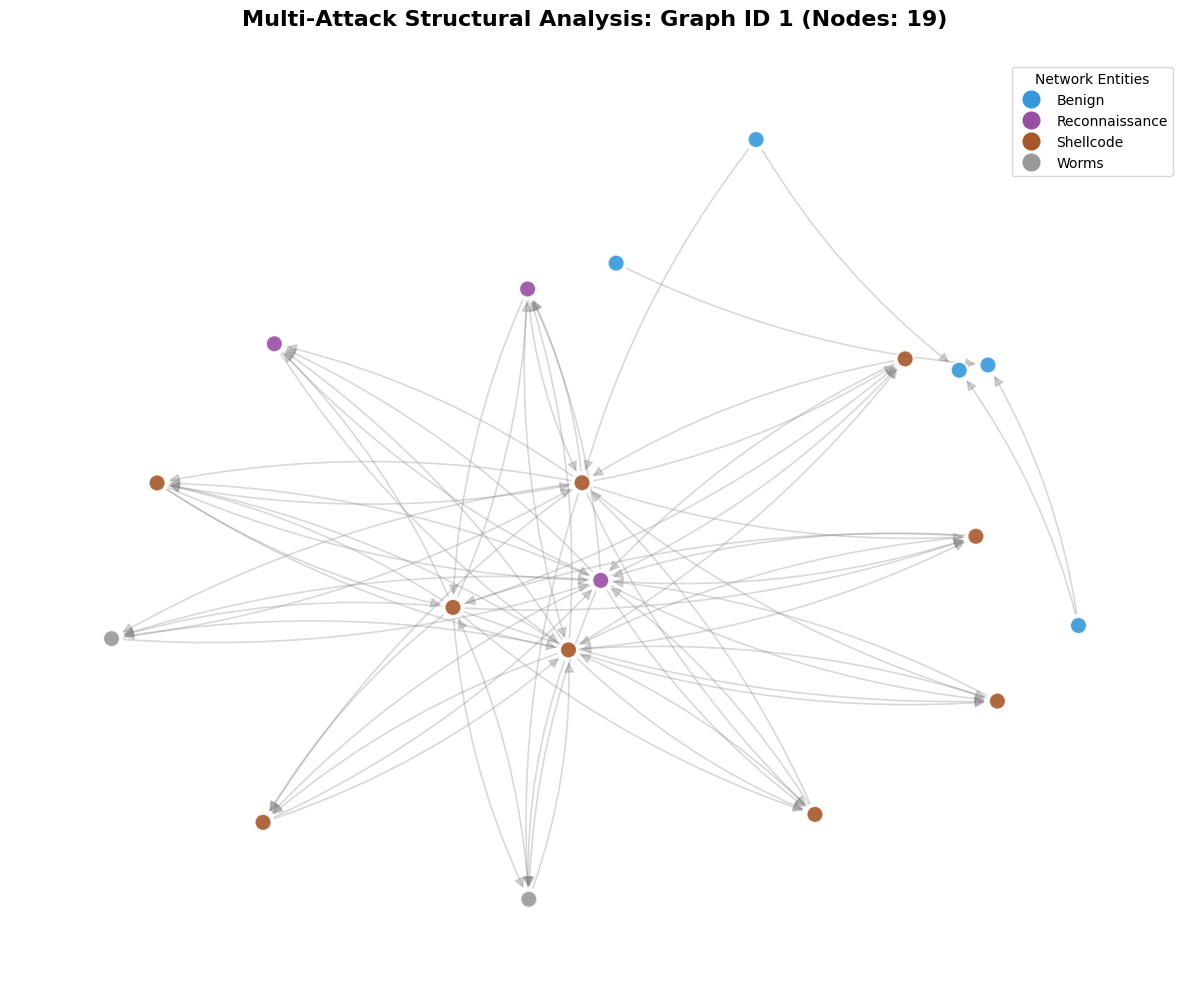

In [6]:
# Show graphs ID 1 and 2 as an example of the complex network
f.plot_complex_graph_binary(complex_df, 2)
f.plot_complex_graph_binary(complex_df, 1)
f.plot_complex_graph_multiclass(complex_df, 1)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## The Dataset

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

- DEFINING THE DATASET
    - NF-UQ-NIDS-v2 Network Intrusion Detection Dataset from [Kaggle - https://www.kaggle.com/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset?resource=download](https://www.kaggle.com/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset?resource=download)
    - Entries (Rows): 75,987,976
    - Features (Columns): 46
    - Target Variable (attack): 21 categories
- INITIAL CLEANING
    - Duplicate entries removed
    - Bad IPs (0.0.0.0) kept for further exploration
    - No nulls or problematic entries found
    - Feature names and entry strings normalized
- TABULAR DATASET
    - Statistical analysis and cleaning reducing to:
    - Entries (Rows): 3,799,095 
    - Features (Columns): 13 (For Training)
    - Target Variable (attack): 21 categories
- COMPLEX NETWORK DATASET
    - Grouping of IPs to create a weighted and directed graph creating:
    - Entries (Rows): 241,361
    - Features (Columns): 20
    - Target Variable (attack): 21 categories

---

### DEFINING THE DATASET

**KEY POINTS:**
- NF-UQ-NIDS-v2 Network Intrusion Detection Dataset from [Kaggle - https://www.kaggle.com/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset?resource=download](https://www.kaggle.com/datasets/aryashah2k/nfuqnidsv2-network-intrusion-detection-dataset?resource=download)
- Entries (Rows): 75,987,976
- Features (Columns): 46
- Target Variable (attack): 21 categories

A rigorous dataset to use is the "NF-UQ-NIDS-v2 Network Intrusion Detection Dataset from Kaggle by Arya Shah.  This dataset provides many features that are atypical in a cybersecurity dataset, but unfortunately, a timestamp for each entry interaction within the cybersecurity network is not part of it.  In regards to what is being trained for the AI models, we want the AI models to categorically predict whether an entry is benign (Not a malicious interaction) or one of the 20 malicious categories (Attacks like Denial of Service, Worms, Ransomware, etc.).  This is to say that our AI models will be a classification type model that needs to predict multiple potential outputs - as opposed to the typical and easier binary classification (Model predicts 0 or 1) - which will likely make things very hard for the AI models to train and predict accurately.  This is ideal because we will want to observe a model trained on a very obscure and complex task compared to a model trained on complex network feature engineering that is intended to tell the model what is and isn't important.

---

### INITIAL CLEANING

**KEY POINTS:**
- INITIAL CLEANING
- Duplicate entries removed
- Bad IPs (0.0.0.0) kept for further exploration
- No nulls or problematic entries found
- Feature names and entry strings normalized

Before we can train our model, there's a lot of preprocessing steps that must take place before the model can train on a dataset.  This generally includes things like cleaning the dataset, normalizing words and numerical feature ranges, encoding words as numbers, etc.  In general, we removed any entries with null values, checked for IPs with 0.0.0.0, along with some checks for specific potential accidental input information that shouldn't exist within the dataset.  The 0.0.0.0 IPs were kept initially largely because I'm unaware if there's any intrinsic value to be derived from this information or not which will be later explored primarily with the complex network feature engineering portion.  It should be noted that for expediency's sake, we reduced the original dataset down to 5% of the original amount of entries and we stratified over the target feature which just means that the distribution of the 21 attack categories was maintained when reducing the dataset to 5% of the original amount.  To emphasize, we reduced the number of entries from 75,987,976 entries to 3,799,095 entries.

---

### TABULAR DATASET

**KEY POINTS:**
- Statistical analysis and cleaning reducing to:
- Entries (Rows): 3,799,095 
- Features (Columns): 13 (For Training)
- Target Variable (attack): 21 categories

To ensure that we send the most sensical and explainable information into the AI models, we want to explore the tabular dataset and denote any significant information to either keep, remove, or alter to best accomodate the model training.  Given that I am not a cybersecurity SME and have very minimal exposure to their respective concepts and only garnered what little information from searching and reading articles from open source information, I decided to heavily rely on statistical and associative analysis of every feature to the target feature in order to determine what I should keep and remove.  The reason for both statistical significance and associativity analysis is because the former should tell me that some feature's values are not random and the associativity to observe an actual relationship between the feature and the target feature.  For associativity, I categorized the analysis into four portions.  Minimal association if the analysis is less than 10%, low association if the analysis is less than 30%, moderate association if the analysis is less than 50%, and high association if the analysis is greater than 50%.  Generally, for any categorical feature, like protocols, I used a Chi-Squared contingency for statistical significance and Cramer's V analysis for the feature's association with the target feature.  Respectively, for continuous features - like how many bytes were sent from the source IP to the destination IP - I used the Kruskal Wallis for statistical significance and the Mutual Information for associativity with the target feature.  At the end of this, 26 features were selected to be removed during statistical and associativity analysis and 6 features removed for data-poisoning and useless information reasons leaving 13 features intended for AI model training.  At the end of this removal and exploration, features were encoded and normalized where necessary leaving us with a fully prepared dataset for AI model training on the tabular dataset.

**TABULAR DATASET DATA DICTIONARY**

| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **in_bytes** | `float64` | -0.577, -0.428, -0.523 | Log-transformed and robust-scaled incoming bytes transferred from source to destination. |
| **out_bytes** | `float64` | 0.0, 0.739, 1.321 | Log-transformed and robust-scaled outgoing bytes transferred from destination back to source. |
| **flow_duration_milliseconds** | `float64` | -0.999, 1.451e-05 | Log-transformed and robust-scaled total elapsed time of the flow in milliseconds. |
| **duration_in** | `float64` | -0.020, 0.891, 0.666 | Robust-scaled duration of the active flow in the incoming direction. |
| **min_ttl** | `float64` | -1.0, 0.0, 0.562 | Robust-scaled minimum Time-to-Live (TTL) value observed in the flow. |
| **max_ttl** | `float64` | -1.0, 0.0, 0.562 | Robust-scaled maximum Time-to-Live (TTL) value observed in the flow. |
| **longest_flow_pkt** | `float64` | -0.56, -0.72, -0.52 | Robust-scaled size (in bytes) of the largest packet observed in the flow. |
| **shortest_flow_pkt** | `float64` | 0.0, -0.551, -0.137 | Robust-scaled size (in bytes) of the smallest packet observed in the flow. |
| **max_ip_pkt_len** | `float64` | -0.56, -0.72, -0.52 | Robust-scaled maximum IP packet length observed in the flow. |
| **src_to_dst_avg_throughput** | `float64` | -0.242, -0.523, -0.188 | Log-transformed and robust-scaled average bits per second sent from source to destination. |
| **num_pkts_up_to_128_bytes** | `float64` | -0.333, 0.0, 5.666 | Robust-scaled count of packets in the flow with size ≤ 128 bytes. |
| **num_pkts_128_to_256_bytes** | `float64` | 0.0, 0.5, 1.0 | Robust-scaled count of packets in the flow with size between 128 and 256 bytes. |
| **tcp_win_max_in** | `float64` | 0.125, -0.125, 0.875 | Robust-scaled maximum TCP window size observed for incoming traffic. |
| **attack** | `str` | scanning, benign, ddos | Categorical name of the specific attack type (21 unique tags). |
| **target** | `int64` | 16, 2, 5 | Numerical integer mapping of the attack type for machine learning compatibility. |

![Alt text](finalImages/normalTargetDist.png)

![Alt text](finalImages/normalInbytesAnalysis.png)

![Alt text](finalImages/normalFTPCommandAnalysis.png)

---

### COMPLEX NETWORK DATASET

**KEY POINTS:**

- Grouping of IPs to create a weighted and directed graph creating:
- Entries (Rows): 241,361
- Features (Columns): 20
- Target Variable (attack): 21 categories

Now for the crux of this whole project, deriving and defining complex network information from the tabular dataset in order to create an off-shoot dataset that only consist of complex network data for AI model training.  In general, in order to create a connected network, I had to group entries of the same source nodes, then the same destination nodes, and then their same attack types together and to keep the importance of every connection, every grouping was weighted and directed to help the AI model understand significance between node interactions.  Unfortunately, this created a massively imbalanced dataset where over 99% of the data was a benign entry leaving less than 1% as the malicious data.  (To emphasize, the AI model will be trained on a complex network dataset in which over 99% of the data is benign and less than 1% is malicious which is an important distinguising factor when we observe the AI model performances later.)  At the end of this, we derived various complex network ideology from this graph, explored the newly engineered features, and at the end, we massively reduced the entries from 3,799,095 to 241,361 entires.

**COMPLEX NETWORK DATASET DATA DICTIONARY**
| Feature Name | Dtype | Example | Description |
| :--- | :--- | :--- | :--- |
| **source_ip** | `str` | 0.147.57.10 | Unique identifier for the originating network node. |
| **destination_ip** | `str` | 192.168.1.194 | Unique identifier for the receiving network node. |
| **edge_weight** | `float64` | 840.0 | Raw magnitude of traffic weighting the connection. |
| **is_star_graph** | `int64` | 0, 1 | Boolean flag: 1 if the flow belongs to a hub-and-spoke topology. |
| **is_chain_graph** | `int64` | 1, 0 | Boolean flag: 1 if the flow is part of a sequential multi-hop path. |
| **is_bridge_link** | `int64` | 1, 0 | Boolean flag: 1 if this edge connects two distinct graph islands. |
| **attack** | `str` | benign, ddos | Ground-truth label for security classification. |
| **graph_id** | `int64` | 0, 1, 2 | Unique identifier for the discrete graph island. |
| **baseline_edge_weight_ratio** | `float64` | 0.024786 | Intensity ratio relative to benign topology averages. |
| **baseline_edge_weight_zscore** | `float64` | -0.019630 | Statistical deviation of flow weight from the benign mean. |
| **eigen_1** | `float64` | 654558925.7 | Principal eigenvalue; total structural energy/traffic mass. |
| **eigen_2** | `float64` | 652123263.7 | Second eigenvalue; indicates secondary clusters or hubs. |
| **v1_src** | `float64` | 8.57e-19 | Source component in the first eigenvector (energy hierarchy). |
| **v2_src** | `float64` | 4.45e-19 | Source component in the second eigenvector (cluster role). |
| **src_pagerank** | `float64` | 0.009910 | Influence score identifying source popularity in the graph. |
| **dst_pagerank** | `float64` | 0.003442 | Influence score identifying destination IP as a traffic sink. |
| **global_convergence_steps** | `float64` | 3115.0 | The global number of steps before convergence for a specific graph ID |
| **node_convergence_steps** | `float64` | 2.0 | The node specific number of steps before convergence within a specific graph ID |
| **spectral_gap** | `float64` | 2435661.9 | Absolute difference between eigenvalues; measures centralization. |

![Alt text](finalImages/complexTargetDist.png)

![Alt text](finalImages/complexDisconnectedGraph.png)

![Alt text](finalImages/complexStar.png)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Complex Network Feature Engineering

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

**KEY POINTS:**
- Source IPs, destination IPs, and attack types were grouped in order to create a graph (Specifically because it has to be matrix friendly)
- Graph IDs were created to denote sub-graphs that were connected since the overall graph was not
- Edge weights aggregated to maintain importance of interactions between nodes
- Spectral gap is useful for denoting overall graph topology and clustering
- Eigenvectors help differentiate node presence with the overall graph (spectral gap)
- Global/local convergence steps is useful to determine how long until a node becomes "stuck" and can't move around the graph
- PageRank used to help determine importance/density of every node

Now for the primary intent and scope of this project.  In general, mathematic complex networks derive unique patterns, convergences, and expectations throughout the graph that most notably, makes detection of anomalies extremely simplistic via things like spetral gap.  For the case of this project and our limitations in deep fundamental understanding of these concepts, we will simply apply a sort of "broad-stroke" of complex network ideology purely to see if the core concept of complex networks already improve model performance.  If so, this project can and will quickly fall into numerous rabbit holes of specific exploration, experimentation, and research on singular complex network topics.  That being said, we will primarily focus on key ideas that derive patterns and make anomalies very obvious.  Such ideas consists of the spectral gap, eigenvectors, page rank, and random walks (Used to determine steps to convergence within a graph starting at some node to the stationary distribution).

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Model Selection

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

**KEY POINTS:**
- We will use scikit's Random Forest Classifier for the ML models
- We will use create a simple forward-pass with tensorflow for NN models
- The NN will mimic the Random Forest as much as possible (Initial, hidden, output layer)

Now that we have the two distinct datasets prepared and ready for their respective set of model training, we need to create the most streamlined and simplistic enough ML and NN model since the objective is to observe the dataset performance differences and not the type of models or hyperparameter tunings.  With that, the most logical and easiest to explain ML model is scikit's Random Forest Classifier where similar to a decision tree, every tree is randomly trained on a portion of the data and during every decision, the trees take a vote to decide which path to take.  This is largely to help reduce the issue of the large imbalance in the dataset for the complex network.  The NN is more straightforward since we just add a few layers and ensure that it starts at an initial layer, moves through some hidden layers, and arrives at the output layer.  Again, the intent is to isolate the datasets themselves as the key drivers to better performance or not.  Additionally, the reason for adding NNs into the equation is to observe if the tabular data - which is essentially blindly sending data into the model to determine what pattern exists - and the complex show distinct performance differences or not.

In [3]:
# Observe the complex RFC
rf_model = joblib.load('models/ml_complex_model.joblib')
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 3703,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# Observe the complex NN
nn_model = keras.models.load_model('models/nn_complex_model.keras')
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 21)             │           693 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,585 (45.26 KB)

 Trainable params: 3,861 (15.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,724 (30.18 KB)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Tabular vs. Complex Network

- [Back to Table of Contents](#table-of-contents)

</div>

### SUMMARY:

- ML in both sets performed extremely well reinforcing the importance of statistical and premptive data exploration
- Complex ML nearly perfectly identified what is and isn't benign as well as most of the stealthy attacks very well, but very poorly for obvious attacks like DDOS
- The complex NN performed significantly worse than the tabular NN, possibly denoting the NN ignored patterns provided
- Overall, it may be ideal to determine if an incoming connection is obvious, then use the tabular ML, if it may be stealthy, take the time to use the complex ML

As we initially assumed that richer data provides a richer performing model and not just that, but data in which fundamentally explains the identity/footprint of the data will assist the model in learning what is truly valuable and ignore as much of all the other noise as possible.  Most notably, the complex ML model almost perfectly determined what is and isn't a benign connection which is extremely significant given that the dataset was over 99% benign.  Essentially, one would assume the model to perform very poorly at recall akin to the concept of complacency and muscle memory in people where we would ignore incoming information purely because a single stimuli signaled us to perform some routine behavior.  Also most notable is that a lot of the stealthy attacks that both the ML and NN tabular models performed very poorly on, the complex ML almost caught perfectly which to emphasize, these stealthy attacks would have only made up less than .1% of the dataset.  Inversely, the complex ML saw a distinct drop in performance for very heavy and obvious malicious attacks like DDOS where the tabular data performed well with.  This may be due to a "too deep" of an interpretation of the dataset with complex networks, or the more likely argument, the method at which I aggregated the weighted edges failed to maintain the interactions that would otherwise be seen within the tabular dataset.  In short, this is a lack in the model that would be interesting to explore at a later time.  Besides this, the complex NN performed the worst out of all the AI models trained which is another interesting hiccup in expectations.  Initially, the expectation is that giving the NN key patterns of the dataset ahead of time, then the NN shouldn't need to find these itself and simply refine predictions as much as possible out the gate.  The performance metrics of the complex NN appears to narrate the antithetical of this notion potentially signifying that even telling the NN what is important, it will just ignore this.  Again, this would be something for later exploration, but the most likely outcome is due to the NN model structure being too basic or required additional setup with hyperparameters and other switches like attention in order for it to actually perform as expected.

![Alt text](finalImages/mlMetrics.png)
![Alt text](finalImages/nnMetrics.png)

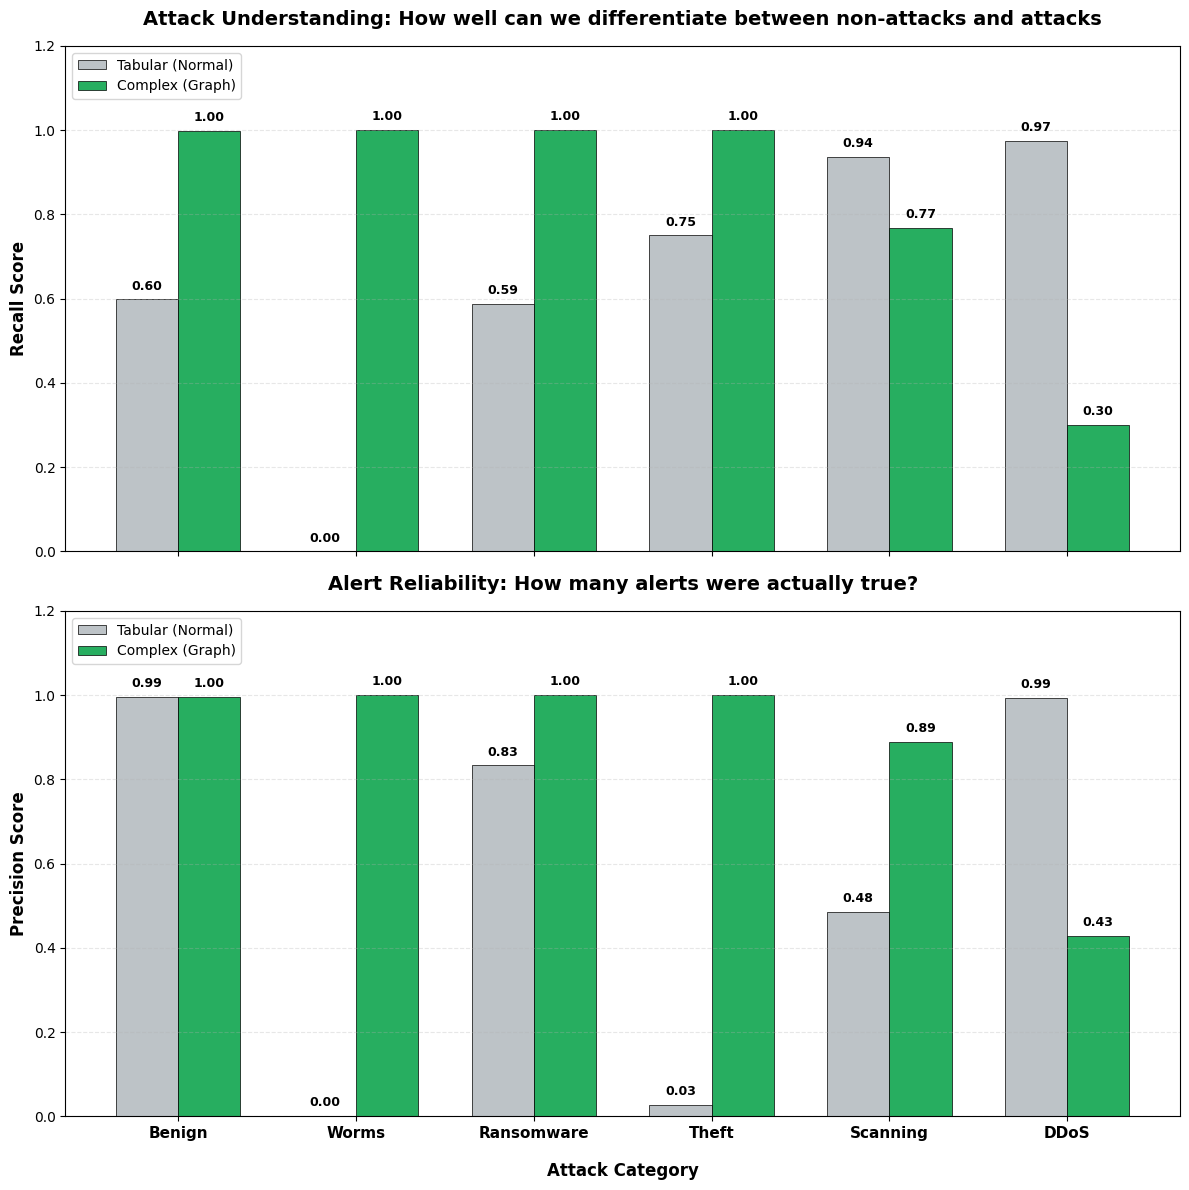

In [2]:
# Observe the key takeaway from performance
f.plot_key_comparison()

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Conclusion

- [Back to Table of Contents](#table-of-contents)

</div>

### KEY TAKEAWAY:

Don't just blindly send data into model training!  At the very least, do your due diligence to understand what the data means in relation to the target and apply statistical and associative analysis.  Outside of this, applying mathematic complex networks may be fundamental to pushing to the next stage in AI - which is already being explored extensively as early as 2025 in response to the cost and large datacenters requirements of current AIs - and is part of things like neuromorphic computing.  If nothing else, once more research is conducted to prove the efficacy, it will provide a very robust method of detecting anomalies and most importantly, if anyone tries to poison the model, complex networks will make this virtually impossible without affecting everything about the model itself!